In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vectorHASH_cont import scaffold_layers, sensory_weights, gridtogrid
from helpers import relu, tanh, softmax, get_mutual_info, get_overlap, noisy_state
from scipy.integrate import solve_ivp
from tqdm import tqdm

## Scaffold Only

In [14]:
def scaffold(t, state, Ng, Nh, W_gg, W_hg, W_gh, lambdas, b, tau_g, tau_h, beta=10):
    g = state[:Ng]
    h = state[Ng:]

    dg = (-g + softmax(W_gg @ g + W_gh @ h, lambdas, 10)) / tau_g
    dh = (-h + relu(W_hg @ g - b)) / tau_h

    return np.concatenate([dg, dh])

def scaffold_vectorized(t, state, Ng, Nh, W_gg, W_hg, W_gh, lambdas, b, tau_g, tau_h, beta=10):
    g = state[:Ng, :]
    h = state[Ng:, :]

    dg = (-g + softmax(W_gg @ g + W_gh @ h, lambdas, 1.0)) / tau_g
    dh = (-h + relu(W_hg @ g - b)) / tau_h

    return np.vstack([dg, dh])

### Testing activation functions

In [10]:
def glob_inh(x, lambdas, inh_stength):
    x1 = x.copy()
    if x.ndim == 1:
        x1 = x[:, None]

    lambdas = np.asarray(lambdas)
    y = np.zeros_like(x1)
    i = 0
    for lam in lambdas:
        size = lam**2
        module = x1[i:i+size, :]
        module_pos = np.where(module > 0, module, 0)
        sq_activity = module_pos*module_pos
        y[i:i+size, :] = sq_activity / (1 + inh_stength * np.sum(sq_activity, axis=0, keepdims=True))
        i += size

    if x.ndim == 1:
        return y[:, 0]
    return y


a = np.random.randn(4)
print(a, a.ndim)
b = softmax(a, [2])
print(b)
print(glob_inh(a, [2], 1))


[ 0.966  0.009  1.234 -0.448] 1
[0.064 0.    0.936 0.   ]
[0.27 0.   0.44 0.  ]


In [11]:
lams = np.array([2,3])          # grid periods
Ng = np.sum(lams*lams)              # number of grid units
patts_total = np.prod(lams*lams)    # total number of patterns possible to store
Nh = 200                            # number of hc units
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
#print(W_gg)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

# testing the weight matrix: grid state should stay at fixed point
g = grid[:, 1]
print(g)
print("0 state:", np.argmax(g[:4]), np.argmax(g[4:]))

for i in range(3):
    g2 = softmax(W_gg @ g, lams, 10)
    print(g2)
    print(f"{i+1} state:", np.argmax(g2[:4]), np.argmax(g2[4:]))
print("\n")

for i in range(5):
    g3 = glob_inh(W_gg @ g, lams, 10)
    print(f"{i+1} state:", np.argmax(g3[:4]), np.argmax(g3[4:]))


[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
0 state: 1 1
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
1 state: 1 1
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
2 state: 1 1
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
3 state: 1 1


1 state: 1 1
2 state: 1 1
3 state: 1 1
4 state: 1 1
5 state: 1 1


### Testing the scaffold

In [22]:
lams = np.array([3, 4, 5]) 
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(1.3, -0.5, lams)

grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0.6)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

# if intial state is a fixed point, should stay at that fixed point
patt = 0
g0 = np.zeros(Ng)
#g0 = grid[:, patt]
h0 = hc[:, patt]
#h0 = np.zeros(Nh)
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 10, 100))

g_traj = sol.y[:Ng, :]   # shape: (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

np.set_printoptions(precision=3, suppress=True)
print(g_traj[:, -1], grid[:, patt])
print(np.allclose(g_traj[:, -1], grid[:,0]))
print(np.linalg.norm(h_traj[:, -1] - h0))           # both may be false because allclose has more stringent tolerance values


[ 1. -0. -0. -0. -0. -0. -0. -0. -0.  1.  0. -0.  0. -0.  0. -0. -0. -0.
 -0. -0. -0. -0. -0.  0. -0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.] [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
False
0.009847231376693244


In [23]:
s_actual = np.sign(W_sh @ h0)

s_recalled = np.sign(W_sh @ h_traj[:, -1])
print(get_overlap(s_recalled, s_actual))   # if overlap is 1, then hc state was recovered correctly
print(np.allclose(s_recalled, sens[:, patt]))

1.0
False


### Adding noise

In [ ]:
patt = 0
#g0 = grid[:, patt] 
g0 = np.zeros(Ng)
h0 = noisy_state(hc[:, patt], 2.001)
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 0.5, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500)
)

g_traj = sol.y[:Ng, :]
h_traj = sol.y[Ng:, :]

print(g_traj[:, -1],grid[:, patt])
print(np.allclose(g_traj[:, -1],grid[:,0]))
print(np.allclose(h0, h_traj[:, -1]))

[ 9.99495219e-01  1.00254135e-22  7.94605785e-18  8.24833893e-09
  4.24959015e-10 -8.80185903e-34 -2.86042446e-32  3.37293820e-22
  4.16764933e-08  9.99495269e-01  4.62586071e-20  4.06587588e-22
  5.58618733e-17  2.68698337e-23  1.44364310e-17  6.90927114e-25
  3.09481977e-19  4.56132146e-15  1.56366313e-10  8.42296279e-20
  3.36205119e-22  4.06033914e-13  1.05321554e-19  3.10574995e-26
  1.74093744e-20  9.99495269e-01  2.92703840e-21  2.04262817e-21
  2.33861243e-17  1.41796985e-19  6.62209658e-16  4.53439314e-18
  1.80880280e-14  7.42756111e-22  6.69530980e-13  1.66138077e-17
  4.07733884e-20  7.47364252e-15  2.15332754e-21  3.13007550e-17
  6.62964969e-17  1.01515894e-19  4.70922860e-19  2.34057502e-20
  1.52482121e-19  2.58417212e-19  8.42426191e-23  2.10302717e-14
  2.32694926e-19  3.20227704e-22] [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
False
False


In [9]:
s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, -1])
print(get_overlap(s_recalled, sens[:,patt]))   # if overlap is 1, then hc state was recovered correctly
print(np.allclose(s_recalled, sens[:,patt])) 

1.0
True


## The full model

In [29]:
def vectorhash(t, state, Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lambdas, b, tau_g, tau_h, tau_s, beta=10):
    g = state[:Ng]
    h = state[Ng : Ng+Nh]
    s = state[Ng+Nh:]

    dg = (-g + softmax(W_gg @ g + 1*W_gh @ h, lambdas, beta)) / tau_g
    dh = (-h + relu(W_hg @ g + W_hs @ s - b)) / tau_h
    ds = (-s + tanh(W_sh @ h, beta)) / tau_s

    return np.concatenate([dg, dh, ds])

lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)         
patts_total = np.prod(lams*lams)
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens[:, :500], hc)

patt = 26
#g0 = grid[:, patt]
g0 = np.zeros(Ng)
#h0 = hc[:, patt]
h0 = np.zeros(Nh)
s0 = sens[:, patt]
#s0 = s0 * np.sign(np.random.uniform(0, 1, s0.shape) - 0.4)
state0 = np.concatenate([g0, h0, s0])

sol2 = solve_ivp(
    vectorhash, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 1.0, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 10, 100)
)

g_traj2 = sol2.y[:Ng, :]
h_traj2 = sol2.y[Ng:Ng+Nh, :]
s_traj2 = sol2.y[Ng+Nh:, :]

np.set_printoptions(precision=3, suppress=True)
print(np.allclose(g_traj2[:, -1],grid[:,patt]))
print(g_traj2[:, -1],grid[:,patt])
print(np.linalg.norm(sens[:, patt] - s_traj2[:, -1]))  
print(get_mutual_info(np.sign(s_traj2[:, -1]), sens[:, patt]))
print(get_mutual_info(np.sign(s0), sens[:, patt]))


False
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.] [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
50.26315290460339
0.30202812664914713
1.0


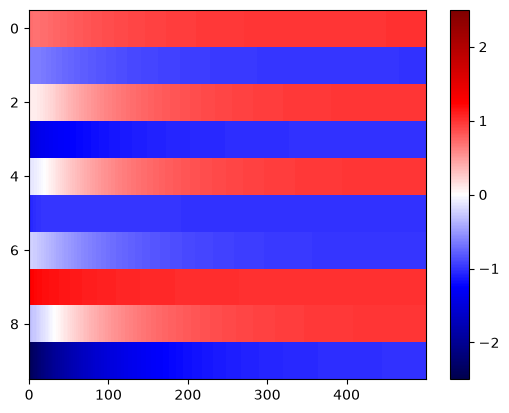

In [46]:
plt.imshow(s_traj2[:10, :], aspect="auto", interpolation="none", vmin=-2.5, vmax=2.5, cmap="seismic")
plt.colorbar()

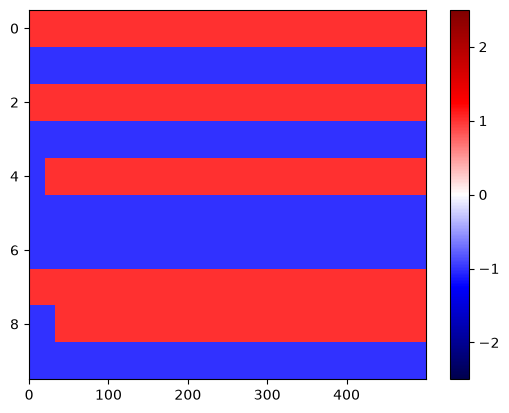

In [50]:
plt.imshow(np.sign(s_traj2[:10, :]), aspect="auto", interpolation="none", vmin=-2.5, vmax=2.5, cmap="seismic")
plt.colorbar()

## Plots

### Fig 2e

In [ ]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0.6)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

mean_hc_norm = np.mean(np.linalg.norm(hc, axis=0))
print(mean_hc_norm.shape)
noise_vals = np.arange(0, 5, 0.25)
runs = 100
correct = np.zeros((runs, len(noise_vals)))
patt = 0
g0 = np.zeros(Ng)
h0 = hc[:,patt] 

for i in range(runs):
    for nidx, noise_val in enumerate((noise_vals)):
        noise = np.random.normal(0, 1, h0.shape) / np.sqrt(Nh)
        h0_noisy = h0 + noise_val*noise*mean_hc_norm
        state0 = np.concatenate([g0, h0_noisy])

        sol = solve_ivp(
                    scaffold, t_span=(0, 10), y0=state0,
                    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0),
                    method='RK45', t_eval=np.linspace(0, 10, 100)
                )

        h_10 = sol.y[Ng:, -1]
        s_recalled = np.sign(W_sh @ h_10)
        err = np.linalg.norm(h_10 - h0)
        correct[i, nidx] = err

()


[[ 0.008  0.008  0.008 ... 15.01  16.56  11.587]
 [ 0.008  0.008  0.008 ... 15.659 18.656 16.459]
 [ 0.008  0.008  0.008 ... 15.484 15.081 19.869]
 ...
 [ 0.008  0.008  0.008 ... 11.968 14.987 17.111]
 [ 0.008  0.008  0.008 ... 12.285 15.764 16.458]
 [ 0.008  0.008  0.008 ... 18.267 15.265 18.69 ]]


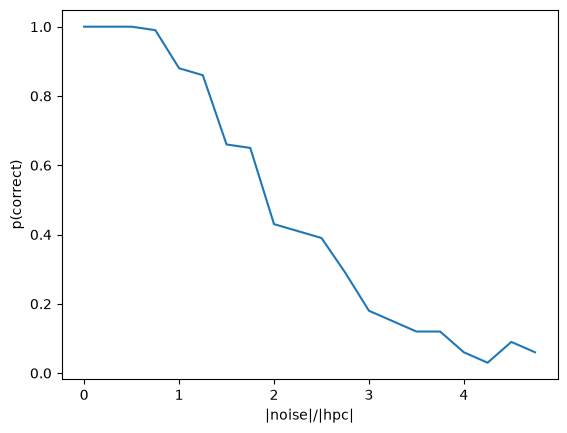

In [29]:
print(correct)
correct_valid = correct<1e-1
correct_avg = correct_valid.mean(axis=0)

plt.plot(noise_vals, correct_avg);
plt.xlabel(r'|noise|/|hpc|');
plt.ylabel('p(correct)');

### Fig 3f

In [18]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens[:, :200], hc)

noise_vals = np.arange(0, 0.55, 0.05)
runs = 100
correct = np.zeros((runs, len(noise_vals)))
patt = 0
g0 = np.zeros(Ng)
h0 = np.zeros(Nh)
s0 = sens[:, patt]
state0 = np.concatenate([g0, h0, s0])
sol = solve_ivp(vectorhash, t_span=(0, 10), y0=state0,
                                args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 1.0, 1.0, 1.0),
                                method='RK45', t_eval=np.linspace(0, 10, 100)
                                )
s_actual = sol.y[Ng+Nh:, -1]  

for i in tqdm(range(runs)):
    for nidx, noise_val in enumerate(noise_vals):
        s0_noisy = s0 * np.sign(np.random.uniform(0, 1, s0.shape) - noise_val)
        state0_noisy = np.concatenate([g0, h0, s0_noisy])

        sol_noisy = solve_ivp(vectorhash, t_span=(0, 10), y0=state0_noisy,
                        args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0.5, 1.0, 1.0, 1.0),
                        method='RK45', t_eval=np.linspace(0, 10, 100)
                        )     
        s_out = sol_noisy.y[Ng+Nh:, -1]
        err = np.linalg.norm(s_out - s_actual)
        correct[i, nidx] = err

100%|██████████| 100/100 [19:38<00:00, 11.79s/it]


54.58849227076531
[[49.828 48.629 47.562 ... 86.253 84.878 82.554]
 [49.828 48.743 49.77  ... 51.594 85.572 82.963]
 [49.828 47.814 46.572 ... 82.476 81.372 83.59 ]
 ...
 [49.828 49.755 50.434 ... 85.722 78.405 82.75 ]
 [49.828 48.129 50.413 ... 46.793 82.88  81.071]
 [49.828 51.449 50.048 ... 76.188 82.004 81.2  ]]


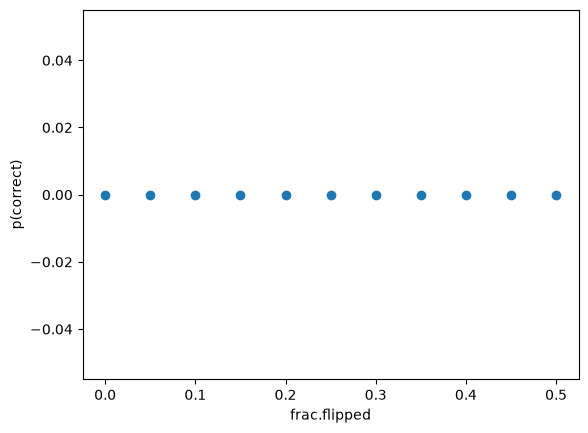

In [21]:
print(np.linalg.norm(s_actual - s0))
print(correct)
correct_valid = correct<5
correct_avg = correct_valid.mean(axis=0)
plt.scatter(noise_vals, correct_avg);
plt.xlabel(r'frac.flipped');
plt.ylabel('p(correct)');

In [ ]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)
sens_patterns = np.sign(np.random.randn(Ns, patts_total))
pattern_range = np.arange(1, patts_total+1, 100)  # list of Npatts to test memory on
plot_list = []

for N_patts in pattern_range:
    sens = sens_patterns[:, :N_patts]
    W_hs, W_sh = sensory_weights(sens, hc)
    

## Adding waves

In [33]:
def square_theta(t, period, phase, duty=0.5):
    tt = (t - phase) % period
    return 1.0 if tt < duty * period else 0.0


def vectorhash_sqwave(t, state, Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lambdas, b, tau_g, tau_h, tau_s,
                     period_g, duty_g, phase_g,
                     period_s, duty_s, phase_s, beta=10):
    g = state[:Ng]
    h = state[Ng : Ng+Nh]
    s = state[Ng+Nh:]

    theta_g = square_theta(t, period_g, phase_g, duty_g)
    theta_s = square_theta(t, period_s, phase_s, duty_s)

    dg = (-g + softmax(W_gg @ g + 1*W_gh @ h, lambdas, beta)) / tau_g
    dh = (-h + relu(theta_g * W_hg @ g + theta_s * W_hs @ s - b)) / tau_h
    ds = (-s + tanh(W_sh @ h, beta)) / tau_s

    return np.concatenate([dg, dh, ds])

lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)         
patts_total = np.prod(lams*lams)
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, 200))
W_hs, W_sh = sensory_weights(sens, hc)

patt = 26
#g0 = grid[:, patt]
g0 = np.zeros(Ng)
#h0 = hc[:, patt]
h0 = np.zeros(Nh)
s0 = sens[:, patt]
state0 = np.concatenate([g0, h0, s0])

period_g, duty_g, phase_g = 0.01, 0.5, 0.0
period_s, duty_s, phase_s = 0.01, 0.5, 0.005

sol2 = solve_ivp(
    vectorhash_sqwave, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 0.01, 0.01, 0.01,
          period_g, duty_g, phase_g,
          period_s, duty_s, phase_s),
    method='RK45', t_eval=np.linspace(0, 5, 500)) #max_step=min(period_g, period_s)*duty_g/5)

g_traj2 = sol2.y[:Ng, :]   
h_traj2 = sol2.y[Ng:Ng+Nh, :]
s_traj2 = sol2.y[Ng+Nh:, :]

print(np.allclose(g_traj2[:, -1],grid[:,patt]))
#print(g_traj2[:, -1],grid[:,patt])
print(np.allclose(h0, h_traj2[:, -1]))
print(get_mutual_info(s_traj2[:, -1], sens[:, patt]))

/tmp/ipykernel_16528/7928383.py:33: RuntimeWarning: overflow encountered in exp
  exp = np.exp(beta * module)
/tmp/ipykernel_16528/7928383.py:34: RuntimeWarning: invalid value encountered in divide
  y[i:i+size, :] = exp / np.sum(exp, axis=0, keepdims=True)


True
False
1.0000194152982265
